# Regimes and transitions — over the federated runs

Refactor of `FLC_033_regimes_and_transitions.ipynb` Part IV. Two things moved, and everything
else follows from them:

* **land use replaced density.** A token is now two alphabets — income `{L,M,H}` and land use
  `{R,M,C,I}` — so one `CODE_ORDER` cannot score it. Scoring runs on **two** axes: an income
  LEVEL rank and a sector SHAPE rank (night/day ordering). Either can be degenerate in a given
  world; that is reported, not silently scored.
* **the signals are FL artifacts, not per-client state-space fits.** Everything is read from
  what `aer_federated_sandbox` saved in `fed_sandbox/<world_id>/<run_id>/`, so §3 scores every
  federated case in `runs.csv` without retraining anything.

Kept: signal / control / ceiling triad, non-cosine similarity, exact `S(N,k)` partition null,
1-D MDS order test, migration test, confound regression. Dropped: `Â_mn`, the centralized
oracle, the `ΔÂ` map — FPL has no off-diagonal block. Cohesion survives as the negative control
and its lagged form keeps a directed `ΔW`.

All logic lives in `fed_regimes.py`; this notebook only chooses, calls and plots.

## 0. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR))
import fed_regimes as fr

ROOT = fr.find_repo_root()
if ROOT is None:
    raise RuntimeError("fedwater repo root not found — run from <repo>/notebooks/prospection/")

SANDBOX = NB_DIR / "fed_sandbox"
WORLDS = fr.list_worlds(ROOT)
TIME = yaml.safe_load((ROOT / "conf" / "base" / "parameters.yml").read_text())["time"]
RES_H = float(TIME["resolution_h"])
REG = fr.registry(SANDBOX)
RUNS = fr.list_runs(SANDBOX)

REG = REG[REG['world_id'].isin(WORLDS.keys())]
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9,
                     "axes.grid": True, "grid.alpha": .25, "legend.frameon": False})

print(f"repo    : {ROOT}")
print(f"sandbox : {SANDBOX}  ({len(RUNS)} saved runs, {len({w for w, _ in RUNS})} worlds)")
_arms = [c for c in ("pp_scaling", "pp_window_size", "m_lstm_units", "t_rounds",
                     "t_proto_alpha", "w_consumption_map", "w_drift_district") if c in REG]
REG[["world_id", "run_id", *_arms]] if not REG.empty else "runs.csv missing — save a run first"

repo    : C:\Users\arthu\USPy\10_Mestrado\fedWater
sandbox : c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\fed_sandbox  (373 saved runs, 61 worlds)


,world_id,run_id,pp_scaling,pp_window_size,m_lstm_units,t_rounds,t_proto_alpha,w_consumption_map,w_drift_district
1,local,20260829-210858_fed_u30_r20_le1_a0.2_agg2h_w24_s6,shared,24,30,20,0.2,NaN,NaN
2,local,20260829-211007_fed_u30_r20_le1_a0.0_agg2h_w24_s6,NaN,24,30,20,0.0,NaN,NaN
3,local,20260829-211128_fed_u30_r20_le1_a0.2_agg2h_w24_s6,NaN,24,30,20,0.2,NaN,NaN
4,local,20260829-211307_fed_u30_r20_le1_a0.2_agg2h_w84...,NaN,84,30,20,0.2,NaN,NaN
5,local,20260829-211555_fed_u30_r40_le1_a0.2_agg2h_w24_s6,NaN,24,30,40,0.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...
368,ef803a0657e2,20260831-035605_fed_u30_r20_le1_a0.0_agg2h_w24_s6,NaN,24,30,20,0.0,LR_LI_LI_LC_LR,District_B
369,ef803a0657e2,20260831-035751_fed_u30_r20_le1_a0.2_agg2h_w24_s6,NaN,24,30,20,0.2,LR_LI_LI_LC_LR,District_B
370,ef803a0657e2,20260831-035953_fed_u30_r20_le1_a0.2_agg2h_w84...,NaN,84,30,20,0.2,LR_LI_LI_LC_LR,District_B
371,ef803a0657e2,20260831-040321_fed_u30_r40_le1_a0.2_agg2h_w24_s6,NaN,24,30,40,0.2,LR_LI_LI_LC_LR,District_B


In [2]:
_labelled = [(w, r) for w, r in RUNS if fr.world_meta(WORLDS, w, REG).get("consumption_map")]
if not _labelled:
    raise RuntimeError("no saved run belongs to a world with a consumption_map "
                       "(a 'local' world carries no meta — build worlds via the experiments engine)")

CONFIG = {
    "world":  _labelled[0][0],     # the run inspected in detail in §2 / §5-7
    "run":    _labelled[0][1],
    "rounds": "all",               # "all" | "last" | [0, 5, 10] — for the round-resolved signal
}
print("focus world :", WORLDS[CONFIG["world"]]["label"])
print("focus run   :", CONFIG["run"])

focus world : 1044dfc219 · baseline · LR_LI_LI_LC_LR
focus run   : 20260830-201447_fed_u30_r20_le1_a0.2_agg2h_w24_s6


## 1. Ground truth — derived, never hardcoded

`consumption_map` is the commissioning state; the drift district switches to
`drift_to_income` / `drift_to_land_use`. The diffusion span is excluded from both phases —
during the ramp neither token is true of the mover, so any window drawn from it is mislabelled
by construction.

In [3]:
META = fr.world_meta(WORLDS, CONFIG["world"], REG)
STATES = fr.regime_states(META)
PHASES = fr.phase_months(WORLDS[CONFIG["world"]], META.get("n_months"))

print(f"consumption_map {META.get('consumption_map')}   beta {META.get('beta')}   "
      f"drift {META.get('drift_district')} -> {META.get('drift_to_income')}/"
      f"{META.get('drift_to_land_use')}")
print(f"init  months {PHASES['init'][:1]}..{PHASES['init'][-1:]}   "
      f"ramp {PHASES['ramp'][:1]}..{PHASES['ramp'][-1:]} (excluded)   "
      f"final {PHASES['final'][:1]}..{PHASES['final'][-1:]}")
for ph in ("init", "final"):
    r = fr.axis_ranks(STATES, ph)
    print(f"{ph:5s}: income contrast {len(set(r['income']))}   "
          f"sector contrast {len(set(r['sector']))}")
STATES

consumption_map LR_LI_LI_LC_LR   beta 0.35   drift District_C -> low/commercial
init  months [0]..[3]   ramp [4]..[14] (excluded)   final [15]..[29]
init : income contrast 1   sector contrast 3
final: income contrast 1   sector contrast 3


,district,token_init,income_init,land_use_init,token_final,income_final,land_use_final,mover
0,District_A,LR,low,residential,LR,low,residential,False
1,District_B,LI,low,industrial,LI,low,industrial,False
2,District_C,LI,low,industrial,LC,low,commercial,True
3,District_D,LC,low,commercial,LC,low,commercial,False
4,District_E,LR,low,residential,LR,low,residential,False


## 2. One run in detail

Seven signals. The one to watch is **0. prototype ladder**: the server already holds those
prototypes, so if the regime is there it costs **zero extra communication** — the uplink
already carries it and the server is simply not listening for it.

Signals 0-2 read the **post-FedAvg** tables (one shared basis, so raw latent features are
comparable across clients). Signal 4 reads the **pre-FedAvg** snapshots, where each client sits
in its own diverged encoder, so it uses only rotation-invariant summaries.

In [4]:
R = fr.score_run(SANDBOX, WORLDS, CONFIG["world"], CONFIG["run"],
                 resolution_h=RES_H, rounds=CONFIG["rounds"], reg=REG)
if R["note"]:
    raise RuntimeError(R["note"])

_view = R["scores"][R["scores"]["round"].isna()]
_view = _view.set_index(["kind", "signal", "phase"])[
    ["k", "ARI", "p_partition", "rho_income", "p_income", "rho_sector", "p_sector", "note"]]
print("ARI: partition recovery vs the joint token (chance 0).  rho_*: does the MDS axis ORDER "
      "the districts?\np is exact and two-sided (the MDS sign is arbitrary).")
_view.round(3).sort_index()

ARI: partition recovery vs the joint token (chance 0).  rho_*: does the MDS axis ORDER the districts?
p is exact and two-sided (the MDS sign is arbitrary).


k    ARI  p_partition  rho_income  \
kind      signal                  phase                                      
ceiling   6. demand profile       final  3  0.375         0.20         NaN   
                                  init   3  0.375         0.20         NaN   
control   5. latent cohesion      final  3 -0.250         0.84         NaN   
                                  init   3 -0.316         1.00         NaN   
federated 0. prototype ladder     final  3  0.375         0.20         NaN   
                                  init   3 -0.250         0.84         NaN   
          1. latent centroid      final  3 -0.250         0.84         NaN   
                                  init   3 -0.250         0.84         NaN   
          2. diurnal norm profile final  3  0.211         0.44         NaN   
                                  init   3  0.375         0.20         NaN   
          3. weight divergence    final  3 -0.316         1.00         NaN   
                                  init   3  0.211         0.44         NaN   

                                         p_income  rho_sector  p_sector note  
kind      signal                  phase                                       
ceiling   6. demand profile       final       NaN       0.527     0.467       
                                  init        NaN      -0.158     0.800       
control   5. latent cohesion      final       NaN      -0.053     0.933       
                                  init        NaN       0.580     0.333       
federated 0. prototype ladder     final       NaN       0.158     0.800       
                                  init        NaN       0.527     0.467       
          1. latent centroid      final       NaN       0.158     0.800       
                                  init        NaN       0.738     0.200       
          2. diurnal norm profile final       NaN      -0.264     0.667       
                                  init        NaN      -0.158     0.800       
          3. weight divergence    final       NaN         NaN       NaN       
                                  init        NaN         NaN       NaN

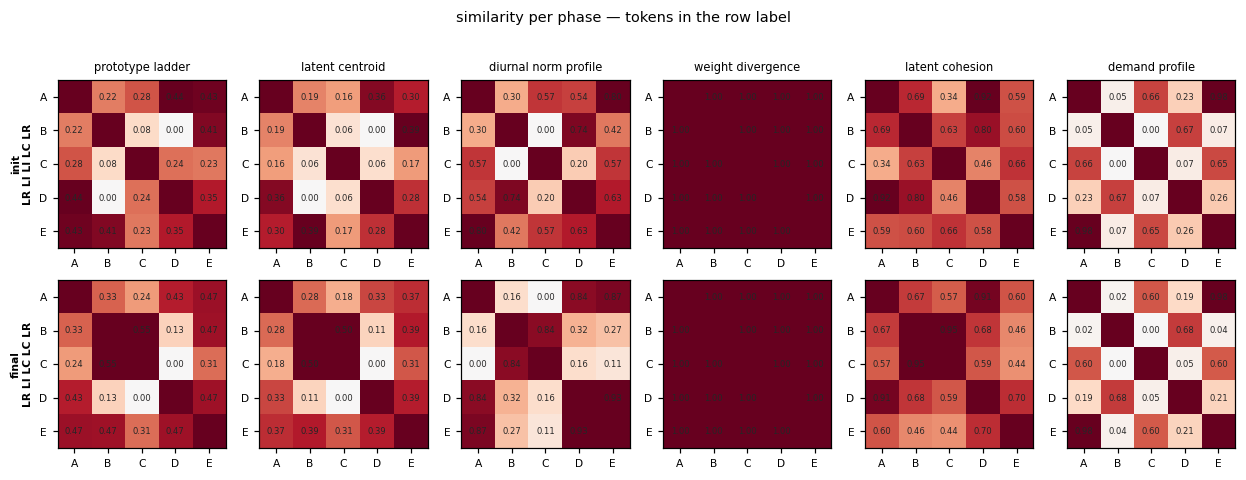

In [5]:
_sigs = sorted({s for _, s in R["S"]})
_phs = [p for p in ("init", "final") if any(p == a for a, _ in R["S"])]
lab = [d[-1] for d in R["districts"]]

fig, axes = plt.subplots(len(_phs), len(_sigs), squeeze=False,
                         figsize=(1.9 * len(_sigs), 2.1 * len(_phs)))
for i, ph in enumerate(_phs):
    for j, name in enumerate(_sigs):
        ax = axes[i][j]
        S = R["S"].get((ph, name))
        if S is None:
            ax.axis("off")
            continue
        v = max(.2, float(np.abs(S - np.eye(len(S))).max()))
        ax.imshow(S, cmap="RdBu_r", vmin=-v, vmax=v)
        ax.set_xticks(range(len(lab)), lab, fontsize=7)
        ax.set_yticks(range(len(lab)), lab, fontsize=7)
        ax.grid(False)
        for a in range(len(lab)):
            for b in range(len(lab)):
                if a != b:
                    ax.text(b, a, f"{S[a, b]:.2f}", ha="center", va="center", fontsize=5.5,
                            color="0.15")
        if i == 0:
            ax.set_title(name.split(". ", 1)[1], fontsize=7.5)
        if j == 0:
            ax.set_ylabel(f"{ph}\n" + " ".join(R["states"][f"token_{ph}"]),
                          fontsize=7, fontweight="bold")
fig.suptitle("similarity per phase — tokens in the row label", y=1.02, fontsize=9.5)
plt.tight_layout()
plt.show()

## 3. Every federated case

One row per `(world, run, phase, signal)`. Scores are pooled by **averaging scores, never
features** — each run is a separately trained model, so its latent basis is arbitrarily rotated
relative to every other and concatenating latents across runs would be meaningless.

In [6]:
ALL = fr.score_all(SANDBOX, WORLDS, resolution_h=RES_H, rounds="last")
if not ALL["notes"].empty:
    print("\nskipped:")
    print(ALL["notes"].to_string(index=False))

SCORES = ALL["scores"]
print(f"\n{len(SCORES)} scored rows over {SCORES['run_id'].nunique()} runs / "
      f"{SCORES['world_id'].nunique()} worlds")
fr.aggregate(SCORES).round(3)

00ac315559 20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w best ARI -0.111  |ρ| 0.707
00ac315559 20260829-212013_fed_u30_r20_le1_a0.0_agg2h_w best ARI +1.000  |ρ| 0.707
00ac315559 20260829-212153_fed_u30_r20_le1_a0.2_agg2h_w best ARI -0.111  |ρ| 0.707
00ac315559 20260829-212407_fed_u30_r20_le1_a0.2_agg2h_w best ARI -0.111  |ρ| 0.707
00ac315559 20260829-212749_fed_u30_r40_le1_a0.2_agg2h_w best ARI -0.111  |ρ| 0.894
00ac315559 20260829-212859_fed_u8_r20_le1_a0.2_agg2h_w2 best ARI -0.111  |ρ| 0.707
07fdd4c1ec 20260829-213051_fed_u30_r20_le1_a0.2_agg2h_w best ARI +1.000  |ρ| 0.866
07fdd4c1ec 20260829-213239_fed_u30_r20_le1_a0.0_agg2h_w best ARI +1.000  |ρ| 0.866
07fdd4c1ec 20260829-213433_fed_u30_r20_le1_a0.2_agg2h_w best ARI +1.000  |ρ| 0.866
07fdd4c1ec 20260829-213645_fed_u30_r20_le1_a0.2_agg2h_w best ARI +1.000  |ρ| 0.866
07fdd4c1ec 20260829-214016_fed_u30_r40_le1_a0.2_agg2h_w best ARI -0.111  |ρ| 0.894
07fdd4c1ec 20260829-214120_fed_u8_r20_le1_a0.2_agg2h_w2 best ARI -0.111  |ρ| 0.866
1044

n    ARI  p_partition  rho_income  \
kind      signal                                                         
ceiling   6. demand profile        480  0.114        0.510         NaN   
control   5. latent cohesion       722  0.050        0.685       0.128   
federated 4. round spectrum        722  0.046        0.683       0.242   
          2. diurnal norm profile  722  0.043        0.683       0.039   
          1. latent centroid       722  0.036        0.698       0.144   
          0. prototype ladder      722  0.030        0.702       0.348   
          3. weight divergence     722 -0.131        0.841         NaN   

                                   rho_sector  p_income  p_sector  \
kind      signal                                                    
ceiling   6. demand profile            -0.189       NaN     0.587   
control   5. latent cohesion            0.110     0.682     0.666   
federated 4. round spectrum             0.083     0.557     0.659   
          2. diurnal norm profile       0.043     0.653     0.609   
          1. latent centroid            0.062     0.653     0.658   
          0. prototype ladder           0.059     0.607     0.642   
          3. weight divergence            NaN       NaN       NaN   

                                   abs_rho_income  abs_rho_sector  
kind      signal                                                   
ceiling   6. demand profile                   NaN           0.406  
control   5. latent cohesion                0.407           0.378  
federated 4. round spectrum                 0.536           0.382  
          2. diurnal norm profile           0.441           0.417  
          1. latent centroid                0.438           0.383  
          0. prototype ladder               0.487           0.392  
          3. weight divergence                NaN             NaN

In [22]:
qwe.shape

(3360, 19)

In [28]:
asd.shape

(264, 16)

In [27]:
qwe = ALL['scores']
qwe = qwe[qwe['world_id'].isin(WORLDS.keys())]
asd = qwe[qwe['ARI'] > 0.6].copy()
asd = asd[['world_id', 'run_id', 'signal', 'round', 'phase', 'k', 'partition',
       'ARI', 'p_partition', 'exact_match', 'note','rho_sector', 'p_sector', 'n_sector', 'kind',
       'n_months_used']]
asd.head()

,world_id,run_id,signal,round,phase,k,partition,ARI,p_partition,exact_match,note,rho_sector,p_sector,n_sector,kind,n_months_used
228,125bcc3f1cb5,20260830-202627_fed_u30_r20_le1_a0.2_agg2h_w24_s6,4. round spectrum,19.0,init,3,034|1|2,1.0,0.04,1.0,,-0.447214,0.600000,3,federated,30
238,125bcc3f1cb5,20260830-202627_fed_u30_r20_le1_a0.2_agg2h_w24_s6,2. diurnal norm profile,NaN,final,3,01|34|2,1.0,0.04,1.0,,0.632456,0.266667,3,federated,30
243,125bcc3f1cb5,20260830-202808_fed_u30_r20_le1_a0.0_agg2h_w24_s6,0. prototype ladder,NaN,init,3,034|2|1,1.0,0.04,1.0,,-0.223607,1.000000,3,federated,30
244,125bcc3f1cb5,20260830-202808_fed_u30_r20_le1_a0.0_agg2h_w24_s6,1. latent centroid,NaN,init,3,034|1|2,1.0,0.04,1.0,,0.223607,1.000000,3,federated,30
256,125bcc3f1cb5,20260830-202950_fed_u30_r20_le1_a0.2_agg2h_w24_s6,4. round spectrum,19.0,init,3,034|1|2,1.0,0.04,1.0,,-0.447214,0.600000,3,federated,30


In [30]:
import numpy as np, pandas as pd
from itertools import permutations
from math import factorial
from collections import Counter
from scipy.stats import binomtest
from sklearn.metrics import adjusted_rand_score as ari
import fed_regimes as fr

SC, SIM, REG = (fr.read_table(SANDBOX / "regime_scores"),
                fr.read_table(SANDBOX / "regime_similarity"), fr.registry(SANDBOX))
ARM = [c for c in ("pp_scaling", "pp_window_size", "m_lstm_units", "t_rounds",
                   "t_proto_alpha") if c in REG]
SC = SC.merge(REG[["run_id", *ARM]], on="run_id", how="left")
SC["arm"] = SC[ARM].astype(str).agg("|".join, axis=1)

# ---- 1. shape-conditional chance, per row -------------------------------
def n_shape(sizes):
    v = factorial(sum(sizes))
    for s in sizes:
        v //= factorial(s)
    for m in Counter(sizes).values():
        v //= factorial(m)
    return v

SC["shape"] = SC["partition"].fillna("").apply(
    lambda s: tuple(sorted((len(b) for b in s.split("|") if b), reverse=True)))
SC["chance"] = SC["shape"].apply(lambda s: 1 / n_shape(s) if s else np.nan)

print(SC.groupby("kind")["exact_match"].agg(hits="sum", n="size", rate="mean").round(4))
print("mean shape-conditional chance:", SC["chance"].mean().round(4))

# ---- 2. is any (signal, phase, arm) cell above chance? ------------------
g = SC.groupby(["kind", "signal", "phase", "arm"]).agg(
    n=("exact_match", "size"), hits=("exact_match", "sum"), chance=("chance", "mean"))
g["p_binom"] = [binomtest(int(h), int(n), float(np.clip(c, 1e-9, .5)), "greater").pvalue
                for h, n, c in g[["hits", "n", "chance"]].to_numpy()]
print(g.sort_values("p_binom").head(15).round(4))

# ---- 3. does the SAME signal win in BOTH phases of the same run? -------
J = SC.pivot_table(index=["world_id", "run_id", "kind", "signal", "arm"],
                   columns="phase", values="exact_match")
J["both"] = J.get("init").eq(1) & J.get("final").eq(1)
print(J.groupby(["kind", "signal"])["both"].agg(both="sum", n="size", rate="mean").round(4))

# ---- 4. hits split by the world's TRUE shape ---------------------------
truth = (SC[SC["exact_match"] == 1].groupby("world_id")["shape"].first())
SC["truth_shape"] = SC["world_id"].map(truth)
print(SC.groupby("truth_shape")["exact_match"].agg(hits="sum", n="size", rate="mean").round(4))

# ---- 5. the decisive test: permutation null on the real matrices -------
TOK = {w: fr.regime_states(fr.world_meta(WORLDS, w, REG)) for w in SC["world_id"].unique()}

def _codes(labels) -> np.ndarray:
    """Opaque labels -> integer ids. np.unique keeps pandas out of it entirely,
    and ARI is invariant to how the ids are numbered."""
    return np.unique(np.asarray(labels, dtype=object), return_inverse=True)[1]


def perm_p(S, tokens):
    y, lab = _codes(tokens), fr.cluster_from_similarity(S, len(set(tokens)))
    real = ari(y, lab)
    null = np.array([ari(_codes(p), lab) for p in set(permutations(tokens))])
    return real, float((null >= real - 1e-12).mean()), float((null >= 1 - 1e-12).mean())

rows = []
for (w, r_, ph, sg), grp in SIM.groupby(["world_id", "run_id", "phase", "signal"]):
    st = TOK[w]
    ds = [d for d in st["district"] if d in set(grp["district_a"])]
    S = (grp.pivot(index="district_a", columns="district_b", values="value")
             .reindex(index=ds, columns=ds).to_numpy())
    toks = list(st.set_index("district").loc[ds, f"token_{'init' if ph == 'init' else 'final'}"])
    real, p, null_hit = perm_p(S, toks)
    rows.append(dict(world_id=w, run_id=r_, phase=ph, signal=sg,
                     ARI=real, p_perm=p, null_hit_rate=null_hit))
P = pd.DataFrame(rows).merge(SC[["world_id", "run_id", "phase", "signal", "kind", "arm"]],
                             on=["world_id", "run_id", "phase", "signal"], how="left")
print(P.groupby(["kind", "signal"])[["ARI", "p_perm", "null_hit_rate"]].mean().round(4))

            hits     n    rate
kind                          
ceiling     24.0   480  0.0500
control     73.0   722  0.1011
federated  244.0  3610  0.0676
mean shape-conditional chance: 0.0965
                                                              n  hits  chance  \
kind      signal                  phase arm                                     
control   5. latent cohesion      init  nan|24|30|20|0.0     60  11.0  0.0917   
federated 0. prototype ladder     init  nan|24|30|20|0.0     60  11.0  0.0967   
control   5. latent cohesion      init  shared|24|30|20|0.2  60   9.0  0.0911   
                                        nan|24|30|20|0.2     60   9.0  0.0911   
federated 1. latent centroid      init  nan|24|30|20|0.0     60   9.0  0.0922   
          0. prototype ladder     init  nan|24|30|15|0.2      1   1.0  0.1000   
          4. round spectrum       final shared|24|30|20|0.2  60   9.0  0.1044   
                                        nan|24|30|20|0.2     60   9.0  0.1044 

In [31]:
from scipy.stats import wilcoxon, kstest, false_discovery_control

# 0. the two data-quality checks first
print(REG.groupby(["pp_scaling"], dropna=False)["scaler_is_per_client"].value_counts())
print("duplicate score rows:",
      SC.duplicated(["world_id", "run_id", "signal", "phase"]).sum())
cov = P.pivot_table(index="world_id", columns="kind", values="ARI", aggfunc="size")
print("worlds missing the ceiling:", int(cov["ceiling"].isna().sum()))

# 1. collapse to one row per (world, signal, phase): MEAN over arms, never max
W = (P.groupby(["world_id", "kind", "signal", "phase"])
      .agg(ARI=("ARI", "mean"), hit=("ARI", lambda s: float((s >= 1 - 1e-12).mean())),
           chance=("null_hit_rate", "mean"), n_arms=("ARI", "size")).reset_index())

# 2. one test per (signal, phase) across the 40 worlds, then FDR
rows = []
for (k, s, ph), g in W.groupby(["kind", "signal", "phase"]):
    a = g["ARI"].to_numpy()
    d = (g["hit"] - g["chance"]).to_numpy()
    rows.append(dict(kind=k, signal=s, phase=ph, n_worlds=len(g),
                     mean_ARI=a.mean(), mean_excess_hit=d.mean(),
                     p_ari=wilcoxon(a, alternative="greater").pvalue if np.ptp(a) else 1.0,
                     p_hit=wilcoxon(d, alternative="greater").pvalue if np.ptp(d) else 1.0))
T = pd.DataFrame(rows)
T["q_ari"] = false_discovery_control(T["p_ari"])
T["q_hit"] = false_discovery_control(T["p_hit"])
print(T.sort_values("p_ari").round(4).to_string(index=False))

# 3. is p_perm even uniform? under the global null it must be
for k, g in P.groupby("kind"):
    print(k, "KS vs uniform p =", round(kstest(g["p_perm"], "uniform").pvalue, 4),
          "| share p<0.1 =", round((g["p_perm"] < 0.1).mean(), 4))

# 4. within-world consistency: does ONE signal win across arms, or does the winner rotate?
win = (P[P["kind"] == "federated"].loc[lambda d: d.groupby(["world_id", "run_id", "phase"])
                                                  ["ARI"].idxmax()])
print(win.groupby("world_id")["signal"].nunique().value_counts().sort_index())

pp_scaling  scaler_is_per_client
shared      True                     40
            False                    22
NaN         True                    192
            False                   118
Name: count, dtype: int64
duplicate score rows: 0
worlds missing the ceiling: 20
     kind                  signal phase  n_worlds  mean_ARI  mean_excess_hit  p_ari  p_hit  q_ari  q_hit
  ceiling       6. demand profile  init        40    0.1776          -0.0500 0.0002 1.0000 0.0029    1.0
federated     0. prototype ladder  init        60    0.0878           0.0433 0.0147 0.7080 0.0880    1.0
federated 2. diurnal norm profile final        60    0.0564           0.0186 0.0665 0.8611 0.2660    1.0
  control      5. latent cohesion  init        60    0.0716           0.0658 0.1377 0.3236 0.4130    1.0
federated      1. latent centroid  init        60    0.0606           0.0454 0.3669 0.9752 0.7967    1.0
  control      5. latent cohesion final        60    0.0289           0.0161 0.4385 0.7729 0.796

In [32]:
# ---- 1. paired, same worlds: does the best federated signal beat the control? ----
piv = (W[W["phase"] == "init"]
       .pivot_table(index="world_id", columns="signal", values="ARI"))
pairs = [("0. prototype ladder", "5. latent cohesion"),
         ("0. prototype ladder", "6. demand profile"),
         ("1. latent centroid", "5. latent cohesion")]
for a, b in pairs:
    d = piv[[a, b]].dropna()
    print(f"{a[:22]:22s} vs {b[:22]:22s} n={len(d):3d} "
          f"delta={d[a].mean()-d[b].mean():+.4f} "
          f"p={wilcoxon(d[a], d[b], alternative='greater').pvalue:.4f}")

# ---- 2. why does `final` collapse? score final matrices with the INIT labels ----
rows = []
for (w, r_, sg), grp in SIM[SIM["phase"] == "final"].groupby(["world_id", "run_id", "signal"]):
    st = TOK[w]
    ds = [d for d in st["district"] if d in set(grp["district_a"])]
    S = (grp.pivot(index="district_a", columns="district_b", values="value")
             .reindex(index=ds, columns=ds).to_numpy())
    lab = st.set_index("district").loc[ds]
    rows.append(dict(world_id=w, run_id=r_, signal=sg,
                     ari_final_labels=perm_p(S, list(lab["token_final"]))[0],
                     ari_init_labels=perm_p(S, list(lab["token_init"]))[0]))
F = pd.DataFrame(rows)
print(F.groupby("signal")[["ari_final_labels", "ari_init_labels"]].mean().round(4))

# ---- 3. is the ceiling-init effect real, or only the 3|1|1 worlds? ----
shape = SC.groupby("world_id")["truth_shape"].first()
C = W[(W["kind"] == "ceiling") & (W["phase"] == "init")].assign(
    shape=lambda d: d["world_id"].map(shape))
for s, g in C.groupby("shape"):
    p = wilcoxon(g["ARI"], alternative="greater").pvalue if np.ptp(g["ARI"]) else 1.0
    print(f"{str(s):16s} n={len(g):3d} mean ARI {g['ARI'].mean():+.4f}  p={p:.4f}")

0. prototype ladder    vs 5. latent cohesion     n= 60 delta=+0.0162 p=0.2862
0. prototype ladder    vs 6. demand profile      n= 40 delta=-0.0116 p=0.5930
1. latent centroid     vs 5. latent cohesion     n= 60 delta=-0.0110 p=0.6118
                         ari_final_labels  ari_init_labels
signal                                                    
0. prototype ladder               -0.0289           0.0010
1. latent centroid                 0.0114           0.0216
2. diurnal norm profile            0.0572           0.0126
3. weight divergence              -0.0834          -0.1785
5. latent cohesion                 0.0290           0.0374
6. demand profile                  0.0501           0.1612
(2, 2, 1)        n=  9 mean ARI +0.2361  p=0.0078
(3, 1, 1)        n= 17 mean ARI +0.1680  p=0.0246
(3, 2)           n=  4 mean ARI +0.0625  p=0.2500


In [50]:
for c in ["same token", "sector gap", "adjacent", "size gap"]:
    v = B[c].dropna()
    exp = +1 if c == "same token" else -1          # expected direction
    print(f"{c:12s} mean {v.mean():+.3f}  median {v.median():+.3f}  "
          f"share in expected direction {(np.sign(v) == exp).mean():.2f}  n={len(v)}")

same token   mean -0.030  median -0.061  share in expected direction 0.25  n=40
sector gap   mean -0.012  median -0.037  share in expected direction 0.50  n=40
adjacent     mean -0.132  median -0.117  share in expected direction 1.00  n=40
size gap     mean -0.105  median -0.081  share in expected direction 0.75  n=40


In [55]:
def pair_design(states, districts, phase, topology=None, amplitude=None):
    """The design matrix confound_regression fits, exposed for inspection."""
    suf = "init" if phase == "init" else "final"
    st = states.set_index("district")
    gt = {}
    if topology is not None:
        for _, r in topology.iterrows():
            gt[tuple(sorted((r["district_a"], r["district_b"])))] = \
                float(r.get("open_boundary_pipes", 0) or 0)
    rows = []
    for i, j in combinations(range(len(districts)), 2):
        a, b = districts[i], districts[j]
        rows.append({
            "pair": a[-1] + b[-1],
            "same token": float(st.at[a, f"token_{suf}"] == st.at[b, f"token_{suf}"]),
            "sector gap": abs(fr.SECTOR_RANK[st.at[a, f"land_use_{suf}"]]
                              - fr.SECTOR_RANK[st.at[b, f"land_use_{suf}"]]),
            "adjacent": float(gt.get(tuple(sorted((a, b))), 0.0) > 0),
            "size gap": (abs(np.log(amplitude[a]) - np.log(amplitude[b]))
                         if amplitude is not None else 0.0)})
    return pd.DataFrame(rows).set_index("pair")


def fit_pairs(S, X, cols):
    """Standardised OLS of the pair similarities on `cols`."""
    y = np.array([S[i, j] for i, j in combinations(range(len(S)), 2)])
    keep = [c for c in cols if c in X and X[c].std() > 0]
    if not keep:
        return pd.Series(dtype=float)
    A = np.column_stack([np.ones(len(X)), ((X[keep] - X[keep].mean()) / X[keep].std()).to_numpy()])
    return pd.Series(np.linalg.lstsq(A, y, rcond=None)[0], index=["intercept"] + keep)


CORR, FITS = [], []
for w in [x for x in TOK if WORLDS[x]["client_dir"].exists()]:
    st, cd = TOK[w], WORLDS[w]["client_dir"]
    ds = list(st["district"])
    ph = fr.phase_months(WORLDS[w], fr.world_meta(WORLDS, w, REG).get("n_months"))
    S = fr.sig_demand_profile(cd, ph["init"], ds, RES_H)
    if S is None:
        continue
    tp = fr.data_root(WORLDS[w]) / "03_primary/gt_topology.csv"
    X = pair_design(st, ds, "init", pd.read_csv(tp) if tp.exists() else None, amp_of[w])
    CORR.append(X[["same token", "sector gap"]].corr().iloc[0, 1])
    FITS.append({
        "world_id": w,
        "sector_alone": fit_pairs(S, X, ["sector gap", "adjacent", "size gap"]).get("sector gap"),
        "token_alone": fit_pairs(S, X, ["same token", "adjacent", "size gap"]).get("same token"),
        "sector_both": fit_pairs(S, X, ["same token", "sector gap", "adjacent", "size gap"]).get("sector gap")})

F2 = pd.DataFrame(FITS)
print(f"corr(same token, sector gap): mean {np.nanmean(CORR):+.3f}")
print(F2[["sector_alone", "token_alone", "sector_both"]].describe().loc[["mean", "50%"]].round(3))
print("sector_alone in expected direction (<0):",
      round((F2["sector_alone"] < 0).mean(), 2))

NameError: name 'amp_of' is not defined

In [56]:
def worlds_where(worlds, **pred):
    return sorted(w for w, v in worlds.items()
                  if all(str((v.get("meta") or {}).get(k)) == str(val)
                         for k, val in pred.items()))


print(pd.Series({w: (v.get("meta") or {}).get("variant")
                 for w, v in WORLDS.items()}).value_counts(dropna=False))

GROUPS = {t: worlds_where(WORLDS, variant=t) for t in ("isolated", "baseline", "partial")}
print({k: len(v) for k, v in GROUPS.items()})

for tag, ws in GROUPS.items():
    sub = W[(W["phase"] == "init") & W["world_id"].isin(ws)]
    if sub.empty:
        print(f"{tag:9s} — no scored worlds")
        continue
    piv = sub.pivot_table(index="world_id", columns="signal", values="ARI")
    for sig in ("6. demand profile", "0. prototype ladder", "5. latent cohesion"):
        if sig not in piv:
            continue
        v = piv[sig].dropna()
        p = (wilcoxon(v, alternative="greater").pvalue
             if len(v) > 5 and np.ptp(v) > 0 else np.nan)
        print(f"{tag:9s} {sig[:22]:22s} n={len(v):3d} ARI {v.mean():+.4f} "
              f"p={'—' if np.isnan(p) else round(p, 4)}")

baseline    40
None         1
Name: count, dtype: int64
{'isolated': 0, 'baseline': 40, 'partial': 0}
isolated  — no scored worlds
baseline  6. demand profile      n= 40 ARI +0.1776 p=0.0002
baseline  0. prototype ladder    n= 40 ARI +0.1660 p=0.0001
baseline  5. latent cohesion     n= 40 ARI +0.1173 p=0.029
partial   — no scored worlds


In [7]:
# per arm, so a sweep axis (scaling, window, proto_alpha, rounds) can be read off directly
_arm = SCORES.merge(REG[["run_id", *_arms]], on="run_id", how="left") if _arms else SCORES
_by = [c for c in ("pp_scaling", "pp_window_size", "t_proto_alpha", "t_rounds") if c in _arm]
(_arm[_arm["kind"] == "federated"]
 .pivot_table(index=["signal"], columns=_by or ["world_id"],
              values=["ARI", "rho_income"], aggfunc="mean")
 .round(3))

,ARI
pp_scaling,shared
pp_window_size,24.0
t_proto_alpha,0.2
t_rounds,20.0
signal,
0. prototype ladder,0.059
1. latent centroid,0.064
2. diurnal norm profile,0.098
3. weight divergence,-0.137
4. round spectrum,0.071


## 4. Migration — does the mover change company?

Recovering two partitions separately is not the research question. The question is whether the
**same** signal puts the drifting district with its initial peers *and* with its final peers.
Read the failure modes: right at final but wrong at init means the signal is tracking the
*drift*, which is already solved upstream — not the *regime*.

In [8]:
MIG = ALL["migration"]
if MIG.empty:
    print("no mover in these worlds (no drift, or the drift district is not in the run)")
else:
    print(MIG.groupby(["kind", "signal"])["moved_correctly"].mean().round(3).to_string())
MIG[["world_id", "run_id", "signal", "kind", "mover", "token", "k_init", "k_final",
     "with_init", "target_init", "with_final", "target_final", "moved_correctly"]]

kind       signal                 
ceiling    6. demand profile          0.000
control    5. latent cohesion         0.086
federated  0. prototype ladder        0.061
           1. latent centroid         0.086
           2. diurnal norm profile    0.064
           3. weight divergence       0.033


,world_id,run_id,signal,kind,mover,token,k_init,k_final,with_init,target_init,with_final,target_final,moved_correctly
0,00ac315559fc,20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w24_s6,5. latent cohesion,control,E,LI->MI,4,4,{},{},{D},{},False
1,00ac315559fc,20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w24_s6,3. weight divergence,federated,E,LI->MI,4,4,{},{},{},{},True
2,00ac315559fc,20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w24_s6,1. latent centroid,federated,E,LI->MI,4,4,{},{},{},{},True
3,00ac315559fc,20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w24_s6,2. diurnal norm profile,federated,E,LI->MI,4,4,{},{},{},{},True
4,00ac315559fc,20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w24_s6,0. prototype ladder,federated,E,LI->MI,4,4,{},{},{},{},True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2040,ef803a0657e2,20260831-040427_fed_u8_r20_le1_a0.2_agg2h_w24_s6,3. weight divergence,federated,B,LI->LR,3,3,"{A,C}",{C},"{A,C}","{A,E}",False
2041,ef803a0657e2,20260831-040427_fed_u8_r20_le1_a0.2_agg2h_w24_s6,1. latent centroid,federated,B,LI->LR,3,3,"{A,E}",{C},{},"{A,E}",False
2042,ef803a0657e2,20260831-040427_fed_u8_r20_le1_a0.2_agg2h_w24_s6,2. diurnal norm profile,federated,B,LI->LR,3,3,{C},{C},"{D,E}","{A,E}",False
2043,ef803a0657e2,20260831-040427_fed_u8_r20_le1_a0.2_agg2h_w24_s6,6. demand profile,ceiling,B,LI->LR,3,3,{D},{C},{D},"{A,E}",False


## 5. Across communication rounds

The round axis is what the federated framing adds and the state-space version could not have:
regime structure is not a property of a converged model but of a *round*. `round = -1` is the
shared untrained init — any score there is a property of random projection plus the data, not
of training.

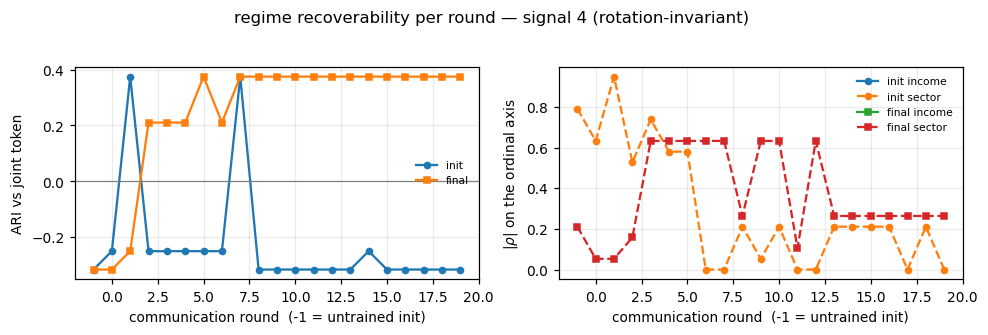

,phase,round,k,ARI,p_partition,rho_income,rho_sector
0,init,-1.0,3,-0.316,1.00,NaN,0.791
1,init,0.0,3,-0.250,0.84,NaN,0.632
2,init,1.0,3,0.375,0.20,NaN,0.949
3,init,2.0,3,-0.250,0.84,NaN,0.527
4,init,3.0,3,-0.250,0.84,NaN,0.738
5,init,4.0,3,-0.250,0.84,NaN,0.580
6,init,5.0,3,-0.250,0.84,NaN,0.580
7,init,6.0,3,-0.250,0.84,NaN,0.000
8,init,7.0,3,0.375,0.20,NaN,0.000
9,init,8.0,3,-0.316,1.00,NaN,0.211


In [9]:
RND = R["scores"][R["scores"]["round"].notna()]
if RND.empty:
    print("no latents_by_round saved for this run (snapshot.every = 0?)")
else:
    fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))
    for ph, m in zip(("init", "final"), ("o", "s")):
        g = RND[RND["phase"] == ph].sort_values("round")
        if g.empty:
            continue
        axes[0].plot(g["round"], g["ARI"], marker=m, ms=4, label=ph)
        axes[1].plot(g["round"], g["rho_income"].abs(), marker=m, ms=4, label=f"{ph} income")
        axes[1].plot(g["round"], g["rho_sector"].abs(), marker=m, ms=4, ls="--",
                     label=f"{ph} sector")
    axes[0].axhline(0, color="0.5", lw=.8)
    axes[0].set_ylabel("ARI vs joint token")
    axes[1].set_ylabel(r"$|\rho|$ on the ordinal axis")
    for ax in axes:
        ax.set_xlabel("communication round  (-1 = untrained init)")
        ax.legend(fontsize=7)
    fig.suptitle("regime recoverability per round — signal 4 (rotation-invariant)", y=1.03)
    plt.tight_layout()
    plt.show()
RND[["phase", "round", "k", "ARI", "p_partition", "rho_income", "rho_sector"]].round(3)

## 6. Confound check

A similarity that scores well is only evidence about regimes once the alternatives are ruled
out: hydraulic adjacency and size both produce regime-looking answers for the wrong reason.
Each district pair is one row, so with `N = 5` there are ten — read the coefficients as
direction, not estimate.

In [10]:
_topo = fr.data_root(WORLDS[CONFIG["world"]]) / "03_primary/gt_topology.csv"
TOPO = pd.read_csv(_topo) if _topo.exists() else None
_pick = ("final", "0. prototype ladder")
if _pick not in R["S"]:
    _pick = sorted(R["S"])[0]
print(f"regressing the '{_pick[1]}' similarity, {_pick[0]} phase"
      + ("" if TOPO is not None else "   (no gt_topology — adjacency dropped)"))
CONFOUND = fr.confound_regression(R["S"][_pick], R["states"], R["districts"], _pick[0],
                                  topology=TOPO)
CONFOUND.round(3)

regressing the '0. prototype ladder' similarity, final phase


,predictor,beta,p_perm
0,intercept,0.340,1.000
1,same token,-0.079,0.444
2,sector gap,-0.031,0.776
3,adjacent,-0.024,0.696


## 7. `ΔW` — the directed object that survives the move to FPL  `[EXTENSION]`

Lagged latent cross-correlation, final minus init. This is **cohesion**, not equivalence: it
says which channel of influence opened, per ordered pair. Physical prediction — a district
whose demand regime rises should draw more through its boundary pipes and become a net
**exporter**.

In [11]:
DW = fr.delta_w(R["run"], R["world"], R["phases"], R["districts"], lag=1)
_mover = R["states"].loc[R["states"]["mover"], "district"]
print("mover:", ", ".join(_mover) or "none",
      "| net exporter ranking below (d_net > 0 = exports more after the drift)")
DW.round(4)

mover: District_C | net exporter ranking below (d_net > 0 = exports more after the drift)


,district,d_out,d_in,d_net
0,E,0.1995,-0.5522,0.7517
1,C,0.3683,0.1455,0.2228
2,B,0.4159,0.4493,-0.0333
3,D,-0.1758,0.1799,-0.3557
4,A,-0.1604,0.4250,-0.5854


## 8. Verdict

In [12]:
def verdict(scores: pd.DataFrame, mig: pd.DataFrame) -> None:
    fed = scores[scores["kind"] == "federated"]
    ceil = scores[scores["kind"] == "ceiling"]
    ctrl = scores[scores["kind"] == "control"]
    if fed.empty:
        print("nothing scored.")
        return
    key = "ARI" if scores["ARI"].notna().any() else "rho_income"
    best = fed.groupby("signal")[key].mean().sort_values(ascending=False)
    c_best = float(ceil.groupby("signal")[key].mean().max()) if not ceil.empty else np.nan
    k_best = float(ctrl.groupby("signal")[key].mean().max()) if not ctrl.empty else np.nan

    print(f"scored on {key} over {scores['run_id'].nunique()} runs / "
          f"{scores['world_id'].nunique()} worlds\n")
    print(f"ceiling (raw demand, pooled centrally) : {c_best:+.3f}")
    print(f"best federated signal                  : {best.iloc[0]:+.3f}   ({best.index[0]})")
    print(f"negative control (cohesion)            : {k_best:+.3f}")

    if np.isfinite(c_best) and c_best < 0.2:
        print("\n-> the regime is not legible even centrally in these worlds. Any federated "
              "result here is a statement about the DATA, not about the method: widen the "
              "income ladder or pick maps with more contrast before reading the rows above.")
    elif best.iloc[0] >= 0.8 * c_best and best.iloc[0] > max(k_best, 0) + 0.2:
        print("\n-> a federated artifact reaches the centralized ceiling and beats the "
              "cohesion control. The regime is on the wire.")
    elif best.iloc[0] > max(k_best, 0) + 0.2:
        print("\n-> partial: federated signals carry the regime but fall short of the "
              "ceiling, i.e. the FL representation is discarding some of it.")
    else:
        print("\n-> not distinguishable from the cohesion control. Do not read this as "
              "'the regime is absent' — check the contrast columns in §1 and the skipped "
              "runs in §3 first.")

    if not mig.empty:
        ok = mig[mig["kind"] == "federated"]["moved_correctly"]
        print(f"\nmigration: {int(ok.sum())}/{len(ok)} federated (signal, run) pairs put the "
              f"mover with the right company in BOTH phases.")
    deg = scores["note"].fillna("").str.len().gt(0).mean()
    if deg > 0:
        print(f"caveat: {deg:.0%} of rows have a degeneracy note (single-token or k == N "
              f"phases) — the partition test is uninformative there by construction.")


verdict(SCORES, MIG)

scored on ARI over 361 runs / 60 worlds

ceiling (raw demand, pooled centrally) : +0.114
best federated signal                  : +0.046   (4. round spectrum)
negative control (cohesion)            : +0.050

-> the regime is not legible even centrally in these worlds. Any federated result here is a statement about the DATA, not about the method: widen the income ladder or pick maps with more contrast before reading the rows above.

migration: 88/1444 federated (signal, run) pairs put the mover with the right company in BOTH phases.


## 9. Persist

Pooled tables next to `runs.csv`, plus per-run scores and a scalar patch onto each run's
registry row, so the sweep summary can be sorted by regime recovery.

In [13]:
for name, df in (("regime_scores", SCORES), ("regime_migration", MIG),
                 ("regime_similarity", ALL["similarity"])):
    if df is not None and not df.empty:
        fr.write_table(df, SANDBOX / name)
        print(f"{name:20s} {df.shape}")

for (w, r_), g in SCORES.groupby(["world_id", "run_id"]):
    fed = g[g["kind"] == "federated"]
    fr.write_table(g, SANDBOX / w / r_ / "regime_scores")
    fr.patch_registry(SANDBOX, w, r_, {
        "regime_best_signal": (fed.groupby("signal")["ARI"].mean().idxmax()
                               if fed["ARI"].notna().any() else None),
        "regime_best_ari": float(fed["ARI"].max()) if fed["ARI"].notna().any() else np.nan,
        "regime_rho_income": float(fed["rho_income"].abs().max()),
        "regime_rho_sector": float(fed["rho_sector"].abs().max()),
        "regime_ceiling_ari": float(g.loc[g["kind"] == "ceiling", "ARI"].max()),
    })
print("\nregistry patched")
fr.registry(SANDBOX)[["world_id", "run_id", "regime_best_signal", "regime_best_ari",
                      "regime_rho_income", "regime_rho_sector", "regime_ceiling_ari"]]

regime_scores        (4812, 19)
regime_migration     (2045, 16)
regime_similarity    (102250, 7)

registry patched


,world_id,run_id,regime_best_signal,regime_best_ari,regime_rho_income,regime_rho_sector,regime_ceiling_ari
0,2d3d24affd4d,20260829-205835_fed_u30_r15_le1_a0.2_agg2h_w24_s6,0. prototype ladder,1.000000,0.707107,0.447214,NaN
1,local,20260829-210858_fed_u30_r20_le1_a0.2_agg2h_w24_s6,NaN,NaN,NaN,NaN,NaN
2,local,20260829-211007_fed_u30_r20_le1_a0.0_agg2h_w24_s6,NaN,NaN,NaN,NaN,NaN
3,local,20260829-211128_fed_u30_r20_le1_a0.2_agg2h_w24_s6,NaN,NaN,NaN,NaN,NaN
4,local,20260829-211307_fed_u30_r20_le1_a0.2_agg2h_w84...,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
368,ef803a0657e2,20260831-035605_fed_u30_r20_le1_a0.0_agg2h_w24_s6,2. diurnal norm profile,0.375000,NaN,0.790569,0.375
369,ef803a0657e2,20260831-035751_fed_u30_r20_le1_a0.2_agg2h_w24_s6,0. prototype ladder,0.210526,NaN,0.447214,0.375
370,ef803a0657e2,20260831-035953_fed_u30_r20_le1_a0.2_agg2h_w84...,0. prototype ladder,0.210526,NaN,0.790569,0.375
371,ef803a0657e2,20260831-040321_fed_u30_r40_le1_a0.2_agg2h_w24_s6,2. diurnal norm profile,1.000000,NaN,0.948683,0.375
